Statistical Analysis


In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
le = StandardScaler()

In [10]:
df = pd.read_csv('asthma_balanced.csv')

In [11]:
# Mean , Median , Mode
mean_vals = df.mean(numeric_only=True)
median_vals = df.median(numeric_only=True)
mode_vals = df.mode(numeric_only=True).iloc[0]

print("Mean:\n", mean_vals)
print("\nMedian:\n", median_vals)
print("\nMode:\n", mode_vals)


Mean:
 Gender                       0.493311
Smoking                      0.141722
PhysicalActivity             0.500000
DietQuality                  0.500000
SleepQuality                 0.500000
PollutionExposure            0.500000
PollenExposure               0.500000
DustExposure                 0.500000
PetAllergy                   0.165970
FamilyHistoryAsthma          0.301003
HistoryOfAllergies           0.399247
Eczema                       0.191890
HayFever                     0.253344
GastroesophagealReflux       0.158027
LungFunctionFEV1             0.500000
LungFunctionFVC              0.500000
Wheezing                     0.596154
ShortnessOfBreath            0.500418
ChestTightness               0.503344
Coughing                     0.503344
NighttimeSymptoms            0.602425
ExerciseInduced              0.604933
Diagnosis                    0.051839
Age_Teenager                 0.143813
Age_Adult                    0.335702
Age_Senior                   0.520485
BMI_U

In [12]:
std_vals = df.std(numeric_only=True)
var_vals = df.var(numeric_only=True)

print("\nStandard Deviation:\n", std_vals)
print("\nVariance:\n", var_vals)



Standard Deviation:
 Gender                       0.500060
Smoking                      0.348838
PhysicalActivity             0.500105
DietQuality                  0.500105
SleepQuality                 0.500105
PollutionExposure            0.500105
PollenExposure               0.500105
DustExposure                 0.500105
PetAllergy                   0.372131
FamilyHistoryAsthma          0.458790
HistoryOfAllergies           0.489846
Eczema                       0.393869
HayFever                     0.435017
GastroesophagealReflux       0.364842
LungFunctionFEV1             0.500105
LungFunctionFVC              0.500105
Wheezing                     0.490770
ShortnessOfBreath            0.500104
ChestTightness               0.500093
Coughing                     0.500093
NighttimeSymptoms            0.489499
ExerciseInduced              0.488967
Diagnosis                    0.221749
Age_Teenager                 0.350973
Age_Adult                    0.472334
Age_Senior                  

In [13]:
Q1 = df.quantile(0.25, numeric_only=True)
Q3 = df.quantile(0.75, numeric_only=True)
IQR = Q3 - Q1

print("\nQ1 (25th percentile):\n", Q1)
print("\nQ3 (75th percentile):\n", Q3)
print("\nIQR:\n", IQR)


Q1 (25th percentile):
 Gender                       0.0
Smoking                      0.0
PhysicalActivity             0.0
DietQuality                  0.0
SleepQuality                 0.0
PollutionExposure            0.0
PollenExposure               0.0
DustExposure                 0.0
PetAllergy                   0.0
FamilyHistoryAsthma          0.0
HistoryOfAllergies           0.0
Eczema                       0.0
HayFever                     0.0
GastroesophagealReflux       0.0
LungFunctionFEV1             0.0
LungFunctionFVC              0.0
Wheezing                     0.0
ShortnessOfBreath            0.0
ChestTightness               0.0
Coughing                     0.0
NighttimeSymptoms            0.0
ExerciseInduced              0.0
Diagnosis                    0.0
Age_Teenager                 0.0
Age_Adult                    0.0
Age_Senior                   0.0
BMI_Underweight              0.0
BMI_Normal                   0.0
BMI_Overweight               0.0
BMI_Obese          

In [14]:
df = pd.read_csv('asthma_disease_dataset.csv')


continuous_cols = ['Age', 'BMI', 'PhysicalActivity', 'DietQuality',
                    'SleepQuality', 'PollutionExposure', 'PollenExposure',
                    'DustExposure', 'LungFunctionFEV1', 'LungFunctionFVC']


Q1 = df[continuous_cols].quantile(0.25)
Q3 = df[continuous_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (df[continuous_cols] < lower_bound) | (df[continuous_cols] > upper_bound)

print("Column-wise outlier count:\n", outliers.sum())
print("\nTotal rows with at least one outlier:", outliers.any(axis=1).sum())

Column-wise outlier count:
 Age                  0
BMI                  0
PhysicalActivity     0
DietQuality          0
SleepQuality         0
PollutionExposure    0
PollenExposure       0
DustExposure         0
LungFunctionFEV1     0
LungFunctionFVC      0
dtype: int64

Total rows with at least one outlier: 0


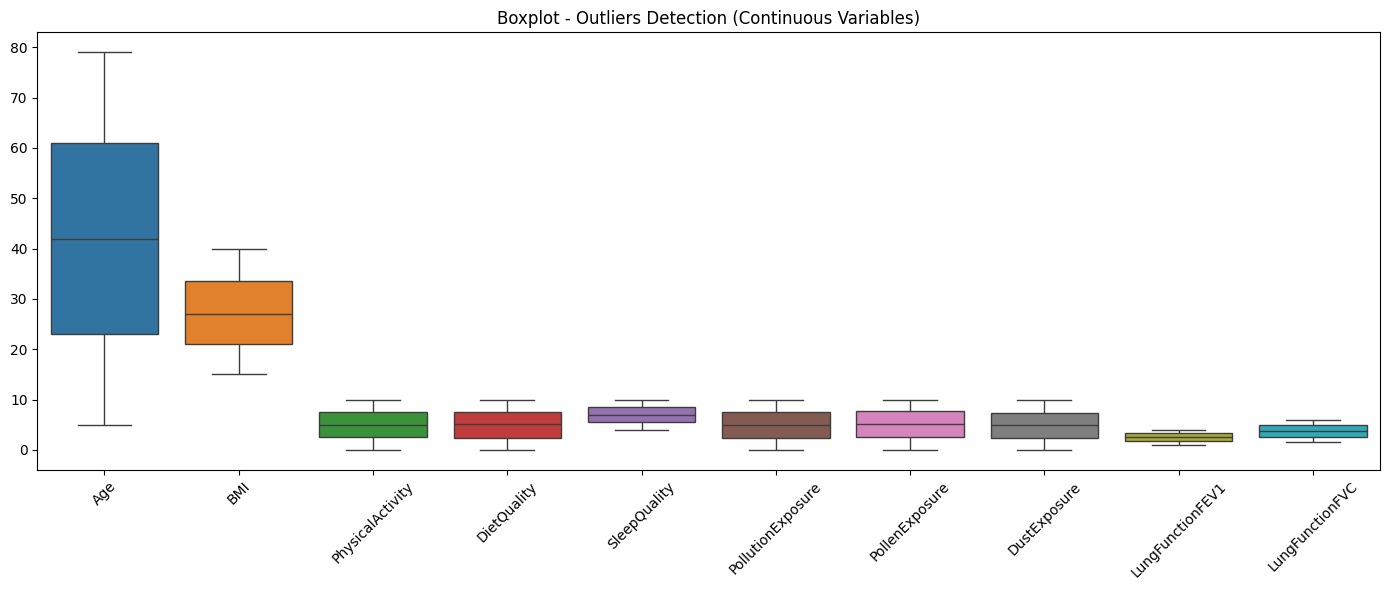

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.boxplot(data=df[continuous_cols])
plt.xticks(rotation=45)
plt.title("Boxplot - Outliers Detection (Continuous Variables)")
plt.tight_layout()
plt.show()

In [21]:
df = pd.read_csv('asthma_balanced.csv')
df_minmax = df.copy()

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    min_val = df[col].min()
    max_val = df[col].max()
    df_minmax[col] = (df[col] - min_val) / (max_val - min_val)

print(df_minmax.head(10))

   Gender  Smoking  PhysicalActivity  DietQuality  SleepQuality  \
0     0.0      0.0               0.0          1.0           1.0   
1     1.0      0.0               1.0          1.0           0.0   
2     0.0      0.0               1.0          1.0           0.0   
3     1.0      0.0               0.0          1.0           0.0   
4     0.0      0.0               0.0          0.0           1.0   
5     0.0      0.0               0.0          0.0           1.0   
6     1.0      1.0               1.0          1.0           0.0   
7     0.0      1.0               1.0          0.0           0.0   
8     1.0      0.0               0.0          0.0           0.0   
9     1.0      0.0               0.0          0.0           1.0   

   PollutionExposure  PollenExposure  DustExposure  PetAllergy  \
0                1.0             0.0           0.0         1.0   
1                0.0             1.0           1.0         0.0   
2                0.0             0.0           1.0         0.0  

In [24]:
df = pd.read_csv('asthma_balanced.csv')
df_zscore = df.copy()

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    mean_val = df[col].mean()
    std_val = df[col].std()
    df_zscore[col] = (df[col] - mean_val) / std_val

print(df_zscore.head(10))


     Gender   Smoking  PhysicalActivity  DietQuality  SleepQuality  \
0 -0.986504 -0.406270         -0.999791     0.999791      0.999791   
1  1.013257 -0.406270          0.999791     0.999791     -0.999791   
2 -0.986504 -0.406270          0.999791     0.999791     -0.999791   
3  1.013257 -0.406270         -0.999791     0.999791     -0.999791   
4 -0.986504 -0.406270         -0.999791    -0.999791      0.999791   
5 -0.986504 -0.406270         -0.999791    -0.999791      0.999791   
6  1.013257  2.460389          0.999791     0.999791     -0.999791   
7 -0.986504  2.460389          0.999791    -0.999791     -0.999791   
8  1.013257 -0.406270         -0.999791    -0.999791     -0.999791   
9  1.013257 -0.406270         -0.999791    -0.999791      0.999791   

   PollutionExposure  PollenExposure  DustExposure  PetAllergy  \
0           0.999791       -0.999791     -0.999791    2.241225   
1          -0.999791        0.999791      0.999791   -0.445998   
2          -0.999791       -0.9

In [25]:
df = pd.read_csv('asthma_balanced.csv')
df_log = df.copy()

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    df_log[col] = np.log1p(df[col])

print(df_log.head(10))

     Gender   Smoking  PhysicalActivity  DietQuality  SleepQuality  \
0  0.000000  0.000000          0.000000     0.693147      0.693147   
1  0.693147  0.000000          0.693147     0.693147      0.000000   
2  0.000000  0.000000          0.693147     0.693147      0.000000   
3  0.693147  0.000000          0.000000     0.693147      0.000000   
4  0.000000  0.000000          0.000000     0.000000      0.693147   
5  0.000000  0.000000          0.000000     0.000000      0.693147   
6  0.693147  0.693147          0.693147     0.693147      0.000000   
7  0.000000  0.693147          0.693147     0.000000      0.000000   
8  0.693147  0.000000          0.000000     0.000000      0.000000   
9  0.693147  0.000000          0.000000     0.000000      0.693147   

   PollutionExposure  PollenExposure  DustExposure  PetAllergy  \
0           0.693147        0.000000      0.000000    0.693147   
1           0.000000        0.693147      0.693147    0.000000   
2           0.000000        0.0